# Retail Demand Forecasting & Inventory Risk Simulation

## Table of Contents

1. Executive Summary

2. Business Problem

3. Data Understanding  
   3.1 Dataset Overview  
   3.2 Data Processing  
   3.3 Feature Engineering  

4. Exploratory Data Analysis

5. Hypothesis Testing

6. Forecasting Model Development  
   6.1. Baseline Model  
   6.2. Forecasting Models  
   6.3. Model Evaluation  
   6.4. Walk-Forward Validation  
   6.5. Model Explainability  
   6.6. Predicted vs Actual Visualization  

7. Forecast Error Analysis  
   7.1. Forecast Error by Weekday  
   7.2. Top Error Days  
   7.3. Error by Demand Volume  
   7.4. Demand Spike Analysis  

8. Business Impact Simulation  
   8.1. Forecast Accuracy Impact  
   8.2. Inventory Optimization  

9. Conclusion & Recommendations

## Executive Summary

Accurate demand forecasting is critical for retail inventory planning, where forecasting errors can lead to stockouts, excess inventory, and inefficient capital allocation.  
This project evaluates whether feature-based machine learning models can improve demand forecasting accuracy compared with a seasonal baseline using large-scale retail transaction data.

### Key Results

| Metric | Result |
|------|------|
| Data Coverage | **10M+ retail transactions (2020–2023)** |
| Evaluation Window | **90-day out-of-sample forecast evaluation** |
| Best Production Model | **HistGradientBoosting** |
| Forecast Accuracy Improvement | **21.8% RMSE reduction vs baseline** |
| Weighted Forecast Error | **4.91% WMAPE** |

### Operational Insight

Error analysis shows that most forecast deviations occur during **high-demand spike periods**, where nonlinear demand patterns are difficult for baseline models to capture.  
Feature-based models significantly improve stability during these demand shifts.

### Business Impact

Forecast improvements reduced total prediction error by **3,329 units** during the evaluation period, equivalent to approximately **1,110 units of forecasting error reduction per month**.

An inventory policy simulation further shows that **a 5% safety buffer minimizes total inventory cost** under the assumed cost structure.

### Inventory Cost Modeling

Inventory cost was modeled using a relative cost index:

- Holding cost = **2 per unit**
- Stockout cost = **8 per unit**

These results demonstrate how **data-driven forecasting can improve demand visibility and support more reliable inventory planning decisions.**


## 2. Business Problem 

Retail demand forecasting is critical for inventory planning and sales operations.

Inaccurate forecasts can lead to:

- Overstock (excess inventory holding cost)
- Stockouts (lost sales opportunities)
- Inefficient inventory allocation across sales channels

#### Objective 
Develop a demand forecasting model that improves prediction accuracy compared to a seasonal baseline. 

#### Key Question 
Can feature-based machine learning models reduce forecasting error in daily retail demand data?

## 3. Data Understanding

### 3.1 Dataset Overview
**Source Data:** `data.zip` containing `data0.csv` – `data9.csv`  
**Schema:** `date`, `cate`, `name`, `mart`, `tot`  
**Derived Features:** `date_day`, `hour`, `weekday`

**Dataset Size**

- Total rows: **10M+**
- Number of files: **10 CSV files**
- Estimated raw size: **~160 MB**  (compressed dataset)

Given the dataset size, the data cannot be safely processed in memory at once.  
Therefore, the preprocessing pipeline uses **chunk-based processing** to ensure memory-efficient handling.

---

#### Data Characteristics & Challenges

The dataset presents several practical challenges commonly encountered in real-world retail data:

- **Large-scale dataset** requiring memory-efficient processing
- **Missing values** (e.g., missing product names)
- **Inconsistent string formatting** (whitespace, inconsistent naming)
- **Zero-sales observations**, which can distort percentage-based error metrics

---

#### Data Quality Considerations

Special care is required during preprocessing to address potential biases in model evaluation:

- Missing product identifiers must be handled carefully
- Text normalization is required to reduce category noise
- Zero-sales observations may distort metrics such as **MAPE**, requiring cautious interpretation

### 3.2 Data Processing

The raw dataset consists of multiple large CSV files compressed in a single archive.

To efficiently process the data while avoiding memory limitations,
the pipeline performs the following steps:

1. Extract the compressed dataset
2. Locate all CSV files
3. Read the data in chunks
4. Clean and normalize string fields
5. Handle missing values
6. Store cleaned chunks as Parquet files

Using chunk-based processing ensures that even very large datasets
can be processed without loading the entire dataset into memory.

In [67]:
import pandas as pd
import numpy as np 
import sklearn 
import lightgbm 
import statsmodels 
import prophet 
import shap 
import plotly 

In [26]:
from prophet import Prophet 
import pandas as pd 
df_test = pd.DataFrame({ "ds": pd.date_range("2024-01-01", periods=30, freq="D"), "y": range(30) }) 
m = Prophet() 
m.fit(df_test) 
future = pd.DataFrame({ "ds": pd.date_range("2024-01-31", periods=7, freq="D") }) 
forecast = m.predict(future) 
forecast[["ds", "yhat"]].head() 

15:26:38 - cmdstanpy - INFO - Chain [1] start processing
15:26:46 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
0,2024-01-31,30.003001
1,2024-02-01,31.003001
2,2024-02-02,32.003001
3,2024-02-03,33.003001
4,2024-02-04,34.003001


In [ ]:
import os, glob, zipfile
from dataclasses import dataclass
from typing import Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f_oneway, pearsonr

pd.set_option("display.max_columns", 50)

@dataclass
class Config:
    zip_path: str = "./data.zip"                                        # data.zip 위치
    extract_dir: str = "./data_extracted"
    out_dir: str = "./output"
    file_pattern: str = "data*.csv"                                     # data0~data9 자동 탐색
    usecols: Tuple[str, ...] = ("date", "cate", "name", "mart", "tot")  # 필요한 컬럼만 로드 (속도/메모리 최적화)
    chunksize: int = 500_000                                            # 대용량 처리용
    parse_date_col: str = "date"

cfg = Config()

def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

ensure_dir(cfg.out_dir)
cfg


Config(zip_path='./data.zip', extract_dir='./data_extracted', out_dir='./output', file_pattern='data*.csv', usecols=('date', 'cate', 'name', 'mart', 'tot'), chunksize=500000, parse_date_col='date')

In [28]:

def unzip_data(cfg: Config) -> None:
    ensure_dir(cfg.extract_dir)
    if not os.path.exists(cfg.zip_path):
        raise FileNotFoundError(f"Zip not found: {cfg.zip_path}")
    with zipfile.ZipFile(cfg.zip_path, "r") as zf:
        zf.extractall(cfg.extract_dir)
    print(f"[OK] Unzipped to: {cfg.extract_dir}")

def find_csv_files(cfg: Config):
    pattern = os.path.join(cfg.extract_dir, "**", cfg.file_pattern)
    files = sorted(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError(f"No CSV files matched pattern: {pattern}")
    print(f"[OK] Found {len(files)} CSV files")
    for f in files[:10]:
        print(" -", f)
    if len(files) > 10:
        print(f" ... and {len(files)-10} more")
    return files


In [29]:

def normalize_simple(s: pd.Series) -> pd.Series:           # 정규표현식을 이용한 단수화 
    s = s.fillna("").astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

### 3.3 Feature Engineering

After cleaning the dataset, several time-based features are created
to capture temporal patterns in sales.

These features help the model identify patterns such as
daily demand cycles and weekday effects.

Engineered features:

- **date_day**: daily-level timestamp for aggregation
- **hour**: hour of the transaction
- **weekday**: day of week (0=Monday)

In [30]:
# --------------------------------------------------
# pd.read_csv를 호출할 때 chunksize=cfg.chunksize 옵션을 사용하여 
# 대용량 데이터를 메모리에 한꺼번에 올리지 않고 나누어 읽어옴. 
# --------------------------------------------------

def iter_clean_chunks(file_path: str, cfg: Config):
    dtype = {"cate": "string", "name": "string", "mart": "string", "tot": "float32"}  # dtype 지정 (메모리 최적화)

    reader = pd.read_csv(
        file_path,
        usecols=list(cfg.usecols),
        chunksize=cfg.chunksize,
        dtype=dtype,
        low_memory=True,
    )

    for chunk in reader:
        chunk[cfg.parse_date_col] = pd.to_datetime(chunk[cfg.parse_date_col], errors="coerce")
        chunk = chunk.dropna(subset=[cfg.parse_date_col, "cate", "tot"])
        chunk = chunk[chunk["tot"] >= 0]

        chunk["cate"] = normalize_simple(chunk["cate"])
        chunk["mart"] = normalize_simple(chunk["mart"])

        # 상품명 결측은 카테고리로 대체 → 데이터 손실 최소화
        chunk["name"] = chunk["name"].fillna(chunk["cate"])
        chunk["name"] = normalize_simple(chunk["name"])

        # --------------------------------------------------
        # Feature Engineering
        # Create time-based features for EDA and forecasting
        # --------------------------------------------------
        chunk["date_day"] = chunk[cfg.parse_date_col].dt.floor("D")
        chunk["hour"] = chunk[cfg.parse_date_col].dt.hour.astype("int16")
        chunk["weekday"] = chunk[cfg.parse_date_col].dt.weekday.astype("int16")

        yield chunk

In [31]:
# --------------------------------------------------
# 각 chunk를 처리한 후 각 청크를 처리한 후, 
# chunk.to_parquet(part_path, index=False) 명령어를 통해 
# ./output/merged_parts 폴더에 
# part_00000.parquet와 같은 형태로 개별 저장
# --------------------------------------------------

def merge_to_parquet_parts(cfg: Config, files):
    part_dir = os.path.join(cfg.out_dir, "merged_parts")
    ensure_dir(part_dir)

    part_idx = 0
    total_rows = 0

    for file_path in files:
        print(f"\n[INFO] Reading: {file_path}")
        for chunk in iter_clean_chunks(file_path, cfg):
            part_path = os.path.join(part_dir, f"part_{part_idx:05d}.parquet")
            chunk.to_parquet(part_path, index=False) 
            total_rows += len(chunk)
            part_idx += 1

            if part_idx % 10 == 0:
                print(f"  ... wrote {part_idx} parts | rows so far: {total_rows:,}")

    print(f"\n[OK] Parts saved at: {part_dir}")
    print(f"[OK] Total cleaned rows: {total_rows:,}")
    return part_dir


In [32]:

part_dir = os.path.join(cfg.out_dir, "merged_parts")
if not os.path.exists(part_dir) or len(glob.glob(os.path.join(part_dir, "*.parquet"))) == 0:
    unzip_data(cfg)
    files = find_csv_files(cfg)
    part_dir = merge_to_parquet_parts(cfg, files)
else:
    print("[OK] parquet parts already exist:", part_dir)

part_dir


[OK] parquet parts already exist: ./output\merged_parts


'./output\\merged_parts'

In [33]:
# --------------------------------------------------
# Load Dataset (Parquet → df)
# 저장된 여러 개의 파켓 파일들을 pd.read_parquet으로 다시 읽어와 하나로 합쳐 사용
# --------------------------------------------------

def load_parts(part_dir: str) -> pd.DataFrame:
    part_files = sorted(glob.glob(os.path.join(part_dir, "*.parquet")))
    if not part_files:
        raise FileNotFoundError(f"No parquet parts found in {part_dir}")
    df = pd.concat((pd.read_parquet(p) for p in part_files), ignore_index=True)
    print(f"[OK] Loaded merged df rows: {len(df):,}")
    return df

df = load_parts(part_dir)
df.head()


[OK] Loaded merged df rows: 10,000,000


,date,cate,name,mart,tot,date_day,hour,weekday
0,2020-01-01 13:32:17,Eggplant Oriental,,2,7.0,2020-01-01,13,2
1,2020-01-01 13:32:37,Ham,Cooked Italian,8,4.0,2020-01-01,13,2
2,2020-01-01 13:36:51,Cheese,Parmesan Cubes,9,3.0,2020-01-01,13,2
3,2020-01-01 13:36:55,Bay Leaf,,2,4.0,2020-01-01,13,2
4,2020-01-01 13:37:26,Bread Fig And Almond,,8,11.0,2020-01-01,13,2


## 4. Exploratory Data Analysis (EDA)

EDA aims to answer three key questions:

1. Are there systematic demand patterns?
2. How large is the variability in daily sales?
3. Are there structural signals useful for forecasting?



In [34]:
# =========================================
# Basic Dataset Overview
# 목적:
# 데이터 규모, 기간, 카테고리 다양성 등을 확인
# =========================================
print("Rows:", len(df))
print("Date range:", df["date"].min(), "~", df["date"].max())
print("Unique cate:", df["cate"].nunique())
print("Unique name (non-empty):", df.loc[df["name"] != "", "name"].nunique())
print("Unique mart (non-empty):", df.loc[df["mart"] != "", "mart"].nunique())
print("Zero-sales rate:", (df["tot"] == 0).mean())
df[["tot"]].describe()


Rows: 10000000
Date range: 2020-01-01 13:30:01 ~ 2023-12-31 23:49:42
Unique cate: 419
Unique name (non-empty): 577
Unique mart (non-empty): 9
Zero-sales rate: 0.0549451


,tot
count,1.000000e+07
mean,9.683823e+00
std,8.120464e+00
min,0.000000e+00
25%,2.000000e+00
50%,8.000000e+00
75%,1.600000e+01
max,3.600000e+01


In [35]:

def eda_and_save(df: pd.DataFrame, cfg: Config) -> Dict[str, object]:
    ensure_dir(cfg.out_dir)

    summary = {
        "n_rows": int(len(df)),
        "date_min": str(df["date"].min()),
        "date_max": str(df["date"].max()),
        "n_cate": int(df["cate"].nunique()),
        "n_name_nonempty": int(df.loc[df["name"] != "", "name"].nunique()),
        "n_mart_nonempty": int(df.loc[df["mart"] != "", "mart"].nunique()),
        "zero_sales_rate": float((df["tot"] == 0).mean()),
    }

    hourly = df.groupby("hour")["tot"].sum().sort_index()
    plt.figure(figsize=(10, 4))
    hourly.plot(kind="bar")
    plt.title("Total Sales by Hour")
    plt.xlabel("Hour"); plt.ylabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_sales_by_hour.png"), dpi=150)
    plt.close()

    weekday = df.groupby("weekday")["tot"].sum().sort_index()
    plt.figure(figsize=(8, 4))
    weekday.plot(kind="bar")
    plt.title("Total Sales by Weekday (0=Mon)")
    plt.xlabel("Weekday"); plt.ylabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_sales_by_weekday.png"), dpi=150)
    plt.close()

    cate_top = df.groupby("cate")["tot"].sum().sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    cate_top.sort_values().plot(kind="barh")
    plt.title("Top 20 Categories by Total Sales")
    plt.xlabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_top20_categories.png"), dpi=150)
    plt.close()

    daily_total = df.groupby("date_day")["tot"].sum().sort_index()
    plt.figure(figsize=(12, 4))
    daily_total.plot()
    plt.title("Daily Total Sales Trend")
    plt.xlabel("Date"); plt.ylabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_daily_total_trend.png"), dpi=150)
    plt.close()

    hourly.to_csv(os.path.join(cfg.out_dir, "table_hourly_sales.csv"))
    weekday.to_csv(os.path.join(cfg.out_dir, "table_weekday_sales.csv"))
    cate_top.to_csv(os.path.join(cfg.out_dir, "table_top20_categories.csv"))
    daily_total.to_csv(os.path.join(cfg.out_dir, "table_daily_total.csv"))

    pd.Series(summary, dtype="object").to_json(os.path.join(cfg.out_dir, "eda_summary.json"), force_ascii=False)
    print(f"[OK] EDA outputs saved to {cfg.out_dir}")
    return summary

summary = eda_and_save(df, cfg)
summary


[OK] EDA outputs saved to ./output


{'n_rows': 10000000,
 'date_min': '2020-01-01 13:30:01',
 'date_max': '2023-12-31 23:49:42',
 'n_cate': 419,
 'n_name_nonempty': 577,
 'n_mart_nonempty': 9,
 'zero_sales_rate': 0.0549451}

In [36]:
daily = df.groupby(["date_day", "weekday"])["tot"].sum().reset_index()
weekday_mean = daily.groupby("weekday")["tot"].mean()
weekday_mean

weekday
0    74489.437500
1    65057.683594
2    63975.343750
3    65342.113281
4    64963.812500
5    65322.085938
6    64858.007812
Name: tot, dtype: float32

### Demand Variability by Category 

Demand characteristics differ across product categories.

To understand how demand scale relates to variability,
the average daily sales and volatility (standard deviation)
are compared across categories.

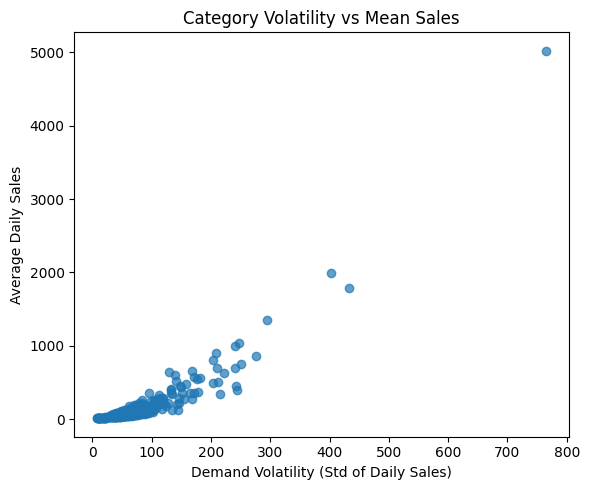

In [37]:
# =========================================
# Category Volatility vs Mean Sales
# 목적:
# 카테고리별 수요 규모와 변동성 관계 확인
# =========================================

cate_daily = (
    df.groupby(["cate", "date_day"])["tot"]
      .sum()
      .reset_index()
)

cate_stats = (
    cate_daily.groupby("cate")["tot"]
    .agg(mean_sales="mean", std_sales="std")
    .reset_index()
)

plt.figure(figsize=(6,5))

plt.scatter(
    cate_stats["std_sales"],
    cate_stats["mean_sales"],
    alpha=0.7
)

plt.xlabel("Demand Volatility (Std of Daily Sales)")
plt.ylabel("Average Daily Sales")
plt.title("Category Volatility vs Mean Sales")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "category_volatility_vs_mean.png"), dpi=150)
plt.show()

### Insight

Categories with higher average demand tend to exhibit
larger demand volatility.

This suggests that high-volume categories may also
be more difficult to forecast due to stronger demand fluctuations.

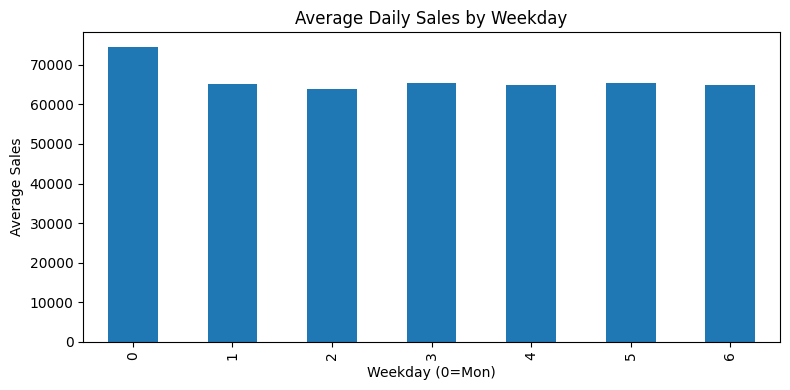

In [38]:
# =========================================
# Visualization: Average Daily Sales by Weekday
# =========================================
plt.figure(figsize=(8,4))

weekday_mean.plot(kind="bar")

plt.title("Average Daily Sales by Weekday")
plt.xlabel("Weekday (0=Mon)")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### Insight

The visualization suggests that sales levels vary across weekdays,
indicating the presence of weekly demand patterns.

Such patterns justify the inclusion of **weekday-based features**
in the forecasting model.

This observation is later validated through statistical hypothesis testing.


## 5. Hypothesis Testing

Exploratory analysis suggested that sales patterns vary across
time dimensions and category characteristics. 

Statistical testing helps validate whether
observed patterns are statistically meaningful
rather than random fluctuations.

To validate whether these observed patterns are statistically meaningful,
three hypotheses are tested:

#### H1. Weekday Effect
Daily total sales differ across weekdays.

#### H2. Hourly Effect
Hourly sales patterns differ across time of day.

#### H3. Demand Volatility by Category
Category-level demand volatility is positively associated with
average sales volume.

These tests provide statistical evidence that demand is not random,
and that forecasting models should account for weekday, hour,
and category-level demand structure.


### Statistical Tests

- **ANOVA** is used to test whether mean sales differ across groups
  (weekday and hour).
- **Pearson correlation** is used to test whether category-level
  demand volatility is associated with average sales.

In [39]:
def hypothesis_tests(df: pd.DataFrame, cfg: Config) -> Dict[str, object]:
    """
    목적: EDA에서 확인한 패턴이 통계적으로 유의한지 검증한다.

    H1: 요일별 일매출 차이가 존재하는가?         -> ANOVA
    H2: 시간대별 판매량 차이가 존재하는가?       -> ANOVA
    H3: 카테고리 평균 판매량과 변동성이 관련 있는가? -> Pearson correlation
    """
    ensure_dir(cfg.out_dir)
    results = {}

    # =========================================
    # H1. Weekday Effect
    # 일별 총 판매량을 요일별로 나누어 평균 차이가 있는지 검정
    # =========================================
    daily = df.groupby("date_day")["tot"].sum().reset_index()
    daily["weekday"] = pd.to_datetime(daily["date_day"]).dt.weekday

    # weekday별 sales array 생성
    weekday_groups = [g["tot"].values for _, g in daily.groupby("weekday")]

    # 그룹이 2개 이상일 때만 ANOVA 수행
    if len(weekday_groups) >= 2:
        f_stat, p_val = f_oneway(*weekday_groups)

        results["H1_anova_weekday_daily_total"] = {
            "f_stat": float(f_stat),
            "p_value": float(p_val)
        }

    # =========================================
    # H2. Hourly Effect
    # 일자-시간 단위 판매량을 기준으로 시간대별 평균 차이를 검정
    # =========================================
    hourly = df.groupby(["date_day", "hour"])["tot"].sum().reset_index()

    # hour별 sales array 생성
    hour_groups = [g["tot"].values for _, g in hourly.groupby("hour")]

    if len(hour_groups) >= 2:
        f_stat, p_val = f_oneway(*hour_groups)

        results["H2_anova_hourly_sales"] = {
            "f_stat": float(f_stat),
            "p_value": float(p_val)
        }

    # =========================================
    # H3. Category-level Volatility vs Mean
    # 카테고리별 일판매량의 평균(mean)과 표준편차(std) 계산
    # 평균 판매량이 큰 카테고리일수록 변동성이 큰지 검정
    # =========================================
    cate_daily = df.groupby(["date_day", "cate"])["tot"].sum().reset_index()

    cate_stats = (
        cate_daily
        .groupby("cate")["tot"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # 관측치가 너무 적은 카테고리는 제외
    # (희소 카테고리는 std 추정이 불안정할 수 있음)
    cate_stats = cate_stats[cate_stats["count"] >= 10]

    if len(cate_stats) >= 3:
        r, p = pearsonr(cate_stats["std"].values, cate_stats["mean"].values)

        results["H3_corr_cate_volatility_vs_mean"] = {
            "pearson_r": float(r),
            "p_value": float(p),
            "n": int(len(cate_stats))
        }

    # =========================================
    # 결과 저장
    # =========================================
    pd.Series(results, dtype="object").to_json(
        os.path.join(cfg.out_dir, "hypothesis_results.json"),
        force_ascii=False
    )

    cate_stats.to_csv(
        os.path.join(cfg.out_dir, "table_cate_stats_mean_std.csv"),
        index=False
    )

    # H3 시각화: 카테고리 평균 판매량 vs 변동성
    if len(cate_stats) >= 3:
        plt.figure(figsize=(6, 5))
        plt.scatter(cate_stats["std"], cate_stats["mean"])
        plt.title("Category Volatility (std) vs Mean Sales")
        plt.xlabel("std (daily sales by category)")
        plt.ylabel("mean (daily sales by category)")
        plt.tight_layout()
        plt.savefig(
            os.path.join(cfg.out_dir, "hypo_scatter_volatility_vs_mean.png"),
            dpi=150
        )
        plt.close()

    print(f"[OK] Hypothesis outputs saved to {cfg.out_dir}")
    return results


# 함수 실행
hypo = hypothesis_tests(df, cfg)
hypo

[OK] Hypothesis outputs saved to ./output


{'H1_anova_weekday_daily_total': {'f_stat': 41.88442611694336, 'p_value': 0.0},
 'H2_anova_hourly_sales': {'f_stat': 7478.626953125, 'p_value': 0.0},
 'H3_corr_cate_volatility_vs_mean': {'pearson_r': 0.9085780382156372,
  'p_value': 0.0,
  'n': 419}}

## 6. Forcasting Model Development

To evaluate forecasting performance more rigorously, multiple models are compared:

1. **Seasonal Naive** – a simple weekly baseline using the previous week's value  
2. **ARIMA** – a classical univariate time-series model  
3. **LightGBM** – a gradient boosting tree model for tabular forecasting features  
4. **HistGradientBoostingRegressor** – a scikit-learn boosting benchmark  
5. **Prophet (optional)** – a decomposable trend/seasonality model if the package is installed

This benchmark design makes it easier to justify model choice and quantify how much each additional modeling approach improves performance over the baseline.


### 6.1 Baseline and Forcasting Models

A stronger benchmark set is used instead of comparing only one baseline against one ML model.

- **Seasonal Naive**: prediction(t) = demand(t-7)
- **ARIMA**: captures autoregressive and moving-average dynamics
- **LightGBM**: handles nonlinear relationships and feature interactions well
- **HistGradientBoosting**: robust tree-based boosting baseline
- **Prophet (optional)**: useful for interpretable trend + seasonality modeling

#### 6.1.1 Baseline Model

In [40]:

def seasonal_naive(y, season=7):
    y = np.asarray(y)
    yhat = np.empty_like(y, dtype=float)
    yhat[:season] = y[:season]
    for i in range(season, len(y)):
        yhat[i] = y[i-season]
    return yhat

#### 6.1.2 Forcasting Models

To improve forecasting accuracy, several time-series features are generated:

**Lag Features**
- Lag 1
- Lag 7
- Lag 14
- Lag 28

**Rolling Statistics**
- 7-day rolling mean
- 7-day rolling standard deviation
- 28-day rolling mean

**Calendar Features**
- Day of week
- Month

These features help the model capture short-term trends,
weekly seasonality, and demand volatility.

In [ ]:

def make_daily_series_for_category(df: pd.DataFrame, cate_name: str, cfg: Config) -> pd.DataFrame:
    ensure_dir(cfg.out_dir)
    sub = df[df["cate"] == cate_name].copy()
    daily = sub.groupby("date_day")["tot"].sum().sort_index().reset_index()
    full_range = pd.date_range(daily["date_day"].min(), daily["date_day"].max(), freq="D") # 모든 날짜 생성
    daily = daily.set_index("date_day").reindex(full_range, fill_value=0).reset_index()    # 판매 없는 날 수량 0으로 채움
    daily.rename(columns={"index": "date_day", "tot": "tot"}, inplace=True)
    daily.to_csv(os.path.join(cfg.out_dir, f"ts_daily_{cate_name}.csv"), index=False)
    return daily

top_cate = df.groupby("cate")["tot"].sum().sort_values(ascending=False).index[0]
ts_daily = make_daily_series_for_category(df, top_cate, cfg)

# Rolling statistics are computed using past observations only.
# The rolling window excludes the current observation to prevent leakage.

def make_features(ts: pd.DataFrame) -> pd.DataFrame:
    d = ts.copy()
    d["date_day"] = pd.to_datetime(d["date_day"])
    d["dow"] = d["date_day"].dt.weekday
    d["month"] = d["date_day"].dt.month
    for lag in [1, 7, 14, 28]:
        d[f"lag_{lag}"] = d["tot"].shift(lag)
    d["roll_mean_7"] = d["tot"].shift(1).rolling(7).mean()
    d["roll_std_7"] = d["tot"].shift(1).rolling(7).std()
    d["roll_mean_28"] = d["tot"].shift(1).rolling(28).mean()
    return d

feat = make_features(ts_daily).dropna().reset_index(drop=True)

### 6.2 Model Training

A **HistGradientBoostingRegressor** is used as the primary forecasting model.

Tree-based gradient boosting models are well suited for this task because:

- they capture nonlinear relationships
- they handle feature interactions effectively
- they perform well on tabular datasets with engineered features

This model is trained using lag and calendar-based predictors
to forecast daily demand.

In [ ]:

# =========================================
# 8.3 Model Training: Multi-model Benchmark
# Seasonal Naive vs ARIMA vs LightGBM vs HistGB vs Prophet(optional)
# =========================================

import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA

# Prophet is optional because the package may not be installed in every environment.
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception:
    PROPHET_AVAILABLE = False


# IMPORTANT:
# The train/test split is performed chronologically to avoid data leakage.
# Future observations are never used to predict past demand.

test_days = 90
train = feat.iloc[:-test_days].copy()
test  = feat.iloc[-test_days:].copy()

target = "tot"
feature_cols = [c for c in feat.columns if c not in ["date_day", target]]

X_train, y_train = train[feature_cols], train[target].values
X_test,  y_test  = test[feature_cols],  test[target].values

# 전체 시계열 (univariate models에서 사용)
full_series = np.r_[y_train, y_test]

# 1) Seasonal Naive baseline
baseline_pred = seasonal_naive(full_series, season=7)[-len(y_test):]

# 2) ARIMA benchmark
# order=(7,1,1)은 주간 seasonality가 강한 일별 데이터에서 자주 쓰는 시작점 (완전 최적화된 통계모델을 위함은 아님)
# auto_arima가 없으므로 보수적인 고정 order를 사용

try:
    arima_model = ARIMA(y_train, order=(7, 1, 1))
    arima_fitted = arima_model.fit()
    arima_pred = np.asarray(arima_fitted.forecast(steps=len(y_test)))
except Exception as e:
    print(f"[WARN] ARIMA failed: {e}")
    arima_pred = np.full(len(y_test), np.nan)

# 3) LightGBM benchmark
lgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)

# 4) HistGradientBoosting benchmark
# HistGradientBoostingRegressor performs well on tabular datasets and handles nonlinear relationships between lag features and demand.
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=10,
    random_state=42
)
hgb_model.fit(X_train, y_train)
hgb_pred = hgb_model.predict(X_test)

# 5) Prophet benchmark (optional)
if PROPHET_AVAILABLE:
    prophet_train = train[["date_day", target]].rename(columns={"date_day": "ds", target: "y"}).copy()
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    prophet_model.fit(prophet_train)

    future = test[["date_day"]].rename(columns={"date_day": "ds"}).copy()
    prophet_forecast = prophet_model.predict(future)
    prophet_pred = prophet_forecast["yhat"].values
else:
    prophet_pred = np.full(len(y_test), np.nan)
    print("[INFO] Prophet is not installed. Skipping Prophet benchmark.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 9
[LightGBM] [Info] Start training from score 5027.430380


15:30:23 - cmdstanpy - INFO - Chain [1] start processing
15:30:24 - cmdstanpy - INFO - Chain [1] done processing


### 6.3 Model Evaluation

Model performance is evaluated using several error metrics:

**RMSE**
Measures the magnitude of prediction errors.

**WMAPE**
Weighted Mean Absolute Percentage Error, which is robust
when zero-sales observations are present.

**sMAPE**
Symmetric MAPE, which normalizes percentage error.

These metrics allow a fair comparison between the baseline model
and the feature-based forecasting model.

In [43]:
def wmape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom != 0 else np.nan

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1.0, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape_zero_adjusted(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100

In [ ]:

# =========================================
# Model Evaluation: Comparison Table
# =========================================

def evaluate_model(y_true, y_pred):
    valid_mask = ~np.isnan(y_pred)
    yt = np.asarray(y_true)[valid_mask]
    yp = np.asarray(y_pred)[valid_mask]
    return {
        "RMSE": rmse(yt, yp),
        "WMAPE(%)": wmape(yt, yp),
        "sMAPE(%)": smape(yt, yp),
        "ZeroAdjMAPE(%)": mape_zero_adjusted(yt, yp),
        "n_eval": int(valid_mask.sum())
    }

model_predictions = {
    "Seasonal Naive": baseline_pred,
    "ARIMA": arima_pred,
    "LightGBM": lgbm_pred,
    "HistGB": hgb_pred,
    "Prophet": prophet_pred
}

comparison_rows = []
for model_name, pred_values in model_predictions.items():
    row = {"Model": model_name}
    row.update(evaluate_model(y_test, pred_values))
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)

# 숫자 보기 좋게 반올림
comparison_df_rounded = comparison_df.copy()
for col in ["RMSE", "WMAPE(%)", "sMAPE(%)", "ZeroAdjMAPE(%)"]:
    comparison_df_rounded[col] = comparison_df_rounded[col].round(2)

comparison_df_rounded.to_csv(os.path.join(cfg.out_dir, "model_benchmark_comparison.csv"), index=False)
comparison_df_rounded


,Model,RMSE,WMAPE(%),sMAPE(%),ZeroAdjMAPE(%),n_eval
0,HistGB,308.75,4.91,4.88,4.89,90
1,LightGBM,313.11,4.99,4.97,4.99,90
2,ARIMA,355.66,5.61,5.57,5.66,90
3,Prophet,372.29,5.71,5.81,5.58,90
4,Seasonal Naive,394.69,5.61,5.62,5.63,90


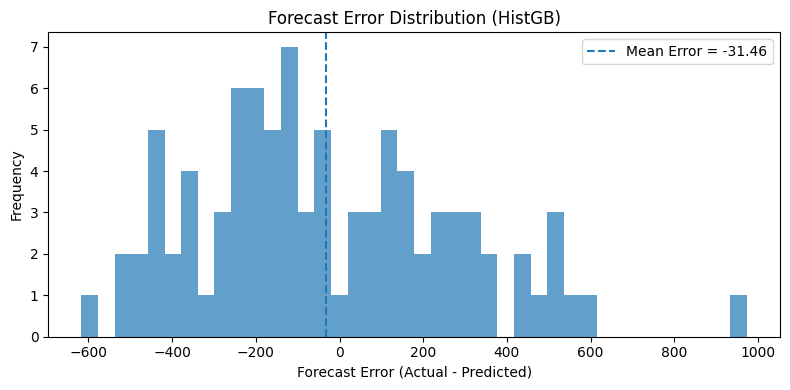

In [ ]:
# =========================================
# Forecast Error Distribution
# 목적: 예측 오차 분포 확인
# =========================================

best_model_name = comparison_df_rounded.iloc[0]["Model"]

pred_map = {
    "Seasonal Naive": baseline_pred,
    "ARIMA": arima_pred,
    "LightGBM": lgbm_pred,
    "HistGB": hgb_pred,
    "Prophet": prophet_pred
}

final_pred = pred_map[best_model_name]

error_df = pd.DataFrame({
    "actual": y_test,
    "pred": final_pred
}).dropna().copy()

error_df["error"] = error_df["actual"] - error_df["pred"]

plt.figure(figsize=(8,4))

plt.hist(error_df["error"], bins=40, alpha=0.7)

mean_error = error_df["error"].mean()

plt.axvline(mean_error, linestyle="--", label=f"Mean Error = {mean_error:.2f}")

plt.title(f"Forecast Error Distribution ({best_model_name})")
plt.xlabel("Forecast Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(cfg.out_dir, f"error_distribution_{best_model_name}.png"),
    dpi=150
)

plt.show()

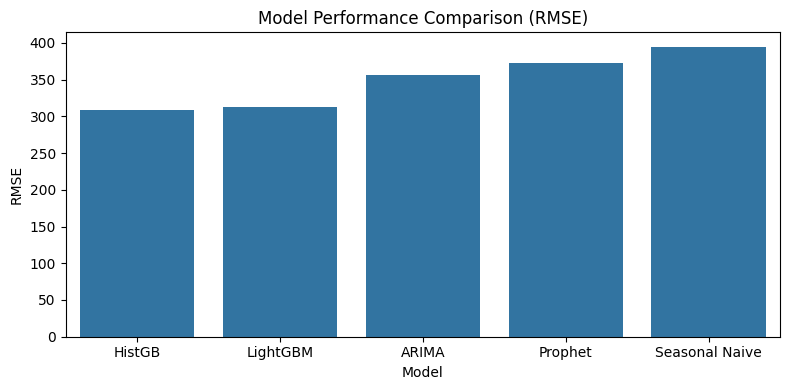

In [69]:
# =========================================
# Model RMSE Comparison
# =========================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.barplot(
    data=comparison_df_rounded,
    x="Model",
    y="RMSE"
)

plt.title("Model Performance Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.tight_layout()
plt.savefig(
    os.path.join(cfg.out_dir, "model_rmse_comparison.png"),
    dpi=150
)

plt.show()

### Insight

The benchmark results show that tree-based models outperform classical statistical models.

HistGradientBoosting achieved the best performance across RMSE and WMAPE, suggesting that nonlinear interactions between lag features and calendar effects are important for short-term demand forecasting.

Summary :

| Model | RMSE |
|------|------:|
| Seasonal Naive | 394.69 |
| Prophet | 372.29 |
| ARIMA | 355.66 |
| LightGBM | 313.11 |
| HistGB | 308.75 |



### 6.4 Walk-Forward Validation

To verify that benchmark results are not dependent on a single train/test split, I performed walk-forward validation using rolling time windows.

This evaluation tests whether the model remains robust across multiple forecasting periods and provides a more realistic estimate of production performance in time-series forecasting.

In [71]:
# =========================================
# Walk-Forward Validation
# 목적:
# 단일 split 대신 rolling 방식으로 모델 안정성 평가
# =========================================

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
import logging
logging.getLogger("cmdstanpy").disabled = True


walk_target = "tot"
walk_features = [c for c in feat.columns if c not in ["date_day", walk_target]]

initial_train_size = 180
step_size = 30
forecast_horizon = 30

wf_rows = []

series_all = feat.reset_index(drop=True).copy()

for train_end in range(initial_train_size, len(series_all) - forecast_horizon + 1, step_size):
    train_fold = series_all.iloc[:train_end].copy()
    test_fold = series_all.iloc[train_end:train_end + forecast_horizon].copy()

    X_train_fold = train_fold[walk_features]
    y_train_fold = train_fold[walk_target].values
    X_test_fold = test_fold[walk_features]
    y_test_fold = test_fold[walk_target].values

    # Seasonal Naive
    full_fold_series = np.r_[y_train_fold, y_test_fold]
    pred_naive = seasonal_naive(full_fold_series, season=7)[-len(y_test_fold):]

    # ARIMA
    try:
        arima_model_fold = ARIMA(y_train_fold, order=(7, 1, 1))
        arima_fit_fold = arima_model_fold.fit()
        pred_arima = np.asarray(arima_fit_fold.forecast(steps=len(y_test_fold)))
    except Exception:
        pred_arima = np.full(len(y_test_fold), np.nan)

    # LightGBM
    lgbm_fold = LGBMRegressor(
        objective="regression",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbosity=-1
    )
    lgbm_fold.fit(X_train_fold, y_train_fold)
    pred_lgbm = lgbm_fold.predict(X_test_fold)

    # HistGB
    hgb_fold = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=10,
        random_state=42
    )
    hgb_fold.fit(X_train_fold, y_train_fold)
    pred_hgb = hgb_fold.predict(X_test_fold)

    # Prophet 
    if "PROPHET_AVAILABLE" in globals() and PROPHET_AVAILABLE:
        try:
            prophet_train_fold = train_fold[["date_day", walk_target]].rename(columns={"date_day": "ds", walk_target: "y"}).copy()
            prophet_model_fold = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False
            )
            prophet_model_fold.fit(prophet_train_fold)

            prophet_future_fold = test_fold[["date_day"]].rename(columns={"date_day": "ds"}).copy()
            prophet_fcst_fold = prophet_model_fold.predict(prophet_future_fold)
            pred_prophet = prophet_fcst_fold["yhat"].values
        except Exception:
            pred_prophet = np.full(len(y_test_fold), np.nan)
    else:
        pred_prophet = np.full(len(y_test_fold), np.nan)

    fold_preds = {
        "Seasonal Naive": pred_naive,
        "ARIMA": pred_arima,
        "LightGBM": pred_lgbm,
        "HistGB": pred_hgb,
        "Prophet": pred_prophet
    }

    for model_name, pred_vals in fold_preds.items():
        valid_mask = ~np.isnan(pred_vals)
        yt = y_test_fold[valid_mask]
        yp = np.asarray(pred_vals)[valid_mask]

        wf_rows.append({
            "train_end_index": train_end,
            "test_start_date": test_fold["date_day"].min(),
            "test_end_date": test_fold["date_day"].max(),
            "model": model_name,
            "RMSE": rmse(yt, yp),
            "WMAPE(%)": wmape(yt, yp),
            "sMAPE(%)": smape(yt, yp),
            "n_eval": len(yt)
        })

walk_forward_df = pd.DataFrame(wf_rows)
walk_forward_df.to_csv(os.path.join(cfg.out_dir, "walk_forward_results.csv"), index=False)

display(walk_forward_df.head())



,train_end_index,test_start_date,test_end_date,model,RMSE,WMAPE(%),sMAPE(%),n_eval
0,180,2020-07-27,2020-08-25,Seasonal Naive,270.797587,5.082244,5.034708,30
1,180,2020-07-27,2020-08-25,ARIMA,345.336721,6.386473,6.266772,30
2,180,2020-07-27,2020-08-25,LightGBM,181.512894,3.354390,3.454941,30
3,180,2020-07-27,2020-08-25,HistGB,215.233571,4.188543,4.233829,30
4,180,2020-07-27,2020-08-25,Prophet,301.735521,6.103609,6.294713,30


In [72]:
# =========================================
# Walk-Forward Summary Table
# =========================================

walk_forward_summary = (
    walk_forward_df
    .groupby("model")[["RMSE", "WMAPE(%)", "sMAPE(%)"]]
    .agg(["mean", "std"])
)

walk_forward_summary.columns = [
    f"{metric}_{stat}" for metric, stat in walk_forward_summary.columns
]
walk_forward_summary = walk_forward_summary.reset_index()

walk_forward_summary.to_csv(os.path.join(cfg.out_dir, "walk_forward_summary.csv"), index=False)
walk_forward_summary.sort_values("RMSE_mean")

,model,RMSE_mean,RMSE_std,WMAPE(%)_mean,WMAPE(%)_std,sMAPE(%)_mean,sMAPE(%)_std
1,HistGB,366.905922,115.639582,5.694987,1.674176,5.718763,1.748614
2,LightGBM,375.352220,121.700971,5.786909,1.800011,5.815883,1.876676
0,ARIMA,407.774085,118.403086,6.250515,1.789327,6.228294,1.833427
4,Seasonal Naive,431.490272,107.043591,6.540246,1.271480,6.548149,1.267885
3,Prophet,434.520639,239.898980,7.110771,4.554490,7.167854,4.743367


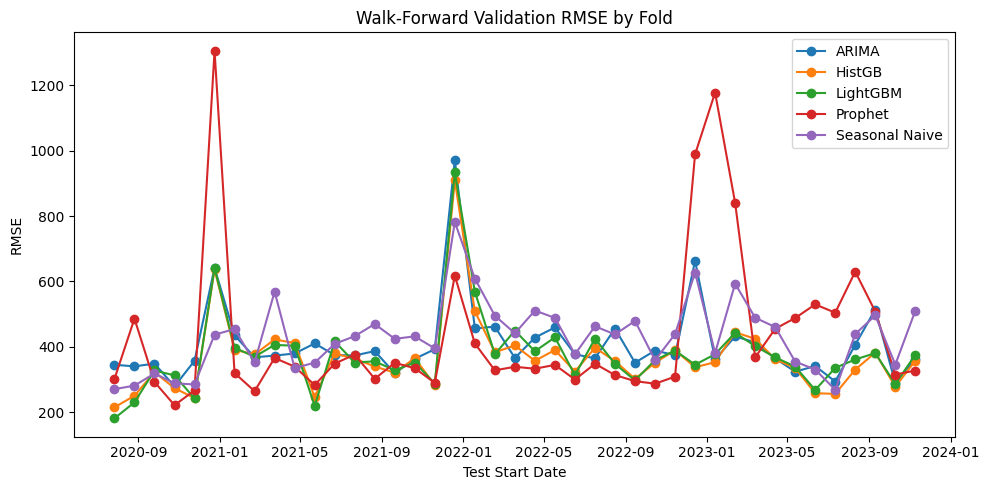

In [73]:
# =========================================
# Walk-Forward RMSE Trend Plot
# =========================================

import matplotlib.pyplot as plt

pivot_rmse = walk_forward_df.pivot_table(
    index="test_start_date",
    columns="model",
    values="RMSE"
)

plt.figure(figsize=(10, 5))
for col in pivot_rmse.columns:
    plt.plot(pivot_rmse.index, pivot_rmse[col], marker="o", label=col)

plt.title("Walk-Forward Validation RMSE by Fold")
plt.xlabel("Test Start Date")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "walk_forward_rmse_trend.png"), dpi=150)
plt.show()

### 6.5 Model Explainability (SHAP)

To understand why the final model performed best, I used SHAP values to measure feature-level contributions.

This helps translate model behavior into interpretable business signals such as trend persistence and weekly seasonality.

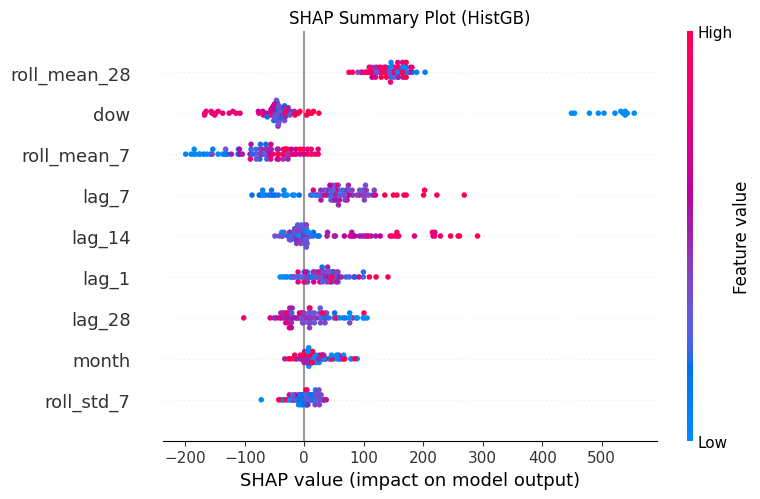

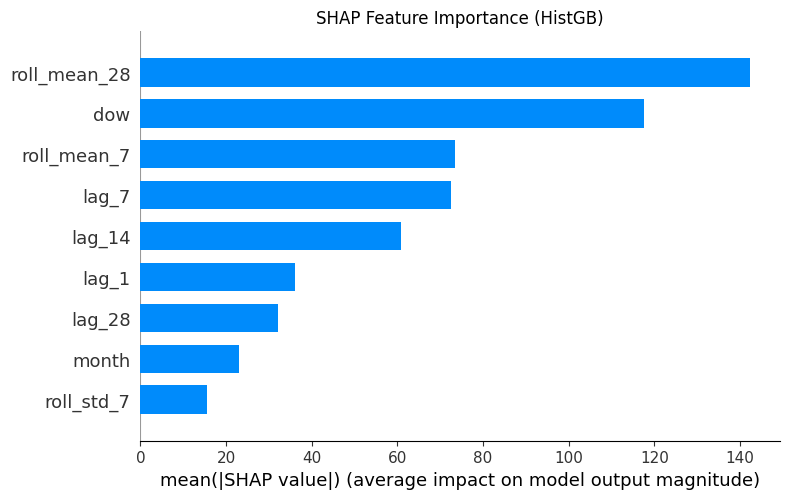

,feature,mean_abs_shap
0,roll_mean_28,142.207963
1,dow,117.461596
2,roll_mean_7,73.500471
3,lag_7,72.581174
4,lag_14,60.949398
5,lag_1,36.206051
6,lag_28,32.216921
7,month,22.914812
8,roll_std_7,15.548860


In [ ]:
# =========================================
# SHAP Feature Importance for Final Model
# 최종 선택 모델(권장: HistGB 또는 LightGBM)의 주요 피처 중요도 해석
# =========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------------------
# 1. 최종 모델 선택
# -----------------------------------------
# 권장:
# - HistGB를 계속 대표 모델로 쓸 경우 -> hgb_model
# - LightGBM이 더 좋으면 -> lgbm_model 로 변경

final_model_name = "HistGB"
final_model = hgb_model
X_explain = X_test.copy()

# -----------------------------------------
# 2. SHAP 계산
# -----------------------------------------
explainer = shap.Explainer(final_model, X_train)
shap_values = explainer(X_explain)

# -----------------------------------------
# 3. Summary Plot (global importance)
# -----------------------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_explain,
    show=False
)

plt.title(f"SHAP Summary Plot ({final_model_name})")
plt.tight_layout()
plt.savefig(
    os.path.join(cfg.out_dir, f"shap_summary_{final_model_name}.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# -----------------------------------------
# 4. Bar Plot (mean absolute SHAP)
# -----------------------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="bar",
    show=False
)

plt.title(f"SHAP Feature Importance ({final_model_name})")
plt.tight_layout()
plt.savefig(
    os.path.join(cfg.out_dir, f"shap_bar_{final_model_name}.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# -----------------------------------------
# 5. Top Feature Importance Table
# -----------------------------------------
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_df.to_csv(
    os.path.join(cfg.out_dir, f"shap_importance_{final_model_name}.csv"),
    index=False
)

shap_importance_df.head(15)

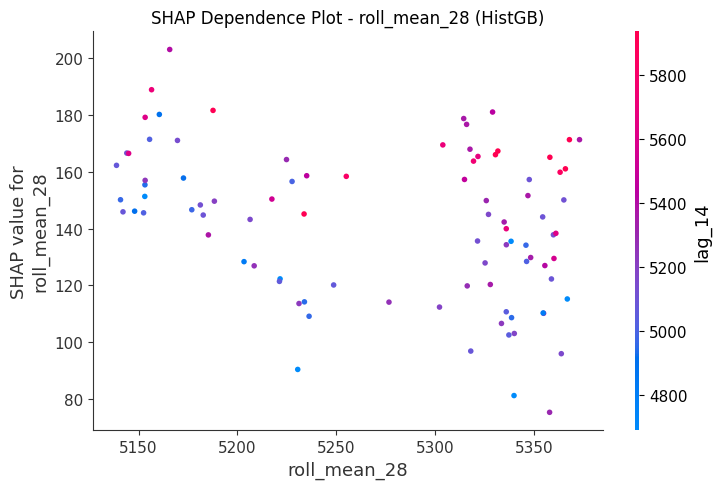

In [ ]:
# =========================================
# Optional: SHAP Dependence Plot
# 상위 중요 피처가 예측값에 어떤 방향으로 작용하는지 확인
# =========================================

top_feature = shap_importance_df.iloc[0]["feature"]

shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_explain,
    show=False
)

plt.title(f"SHAP Dependence Plot - {top_feature} ({final_model_name})")
plt.tight_layout()
plt.savefig(
    os.path.join(cfg.out_dir, f"shap_dependence_{top_feature}_{final_model_name}.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

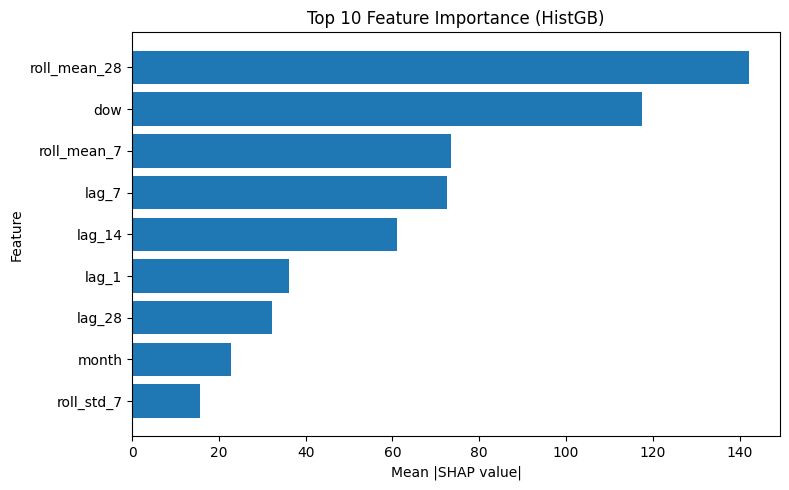

In [76]:
# =========================================
# Optional: Top N SHAP Importance Horizontal Bar Chart
# =========================================

top_n = 10
plot_df = shap_importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importance ({final_model_name})")
plt.tight_layout()
plt.savefig(
    os.path.join(cfg.out_dir, f"shap_top_{top_n}_{final_model_name}.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Insight

SHAP analysis reveals that the model primarily relies on long-term demand trends (28-day rolling mean) and weekly seasonality signals (day-of-week and lag-7 features).

### 6.6 Forecast vs Actual Comparison

To visually assess model performance, predicted demand values
are compared with actual demand values.

If the model performs well, most points should lie close to
the diagonal line, indicating that predictions closely match
the observed demand.

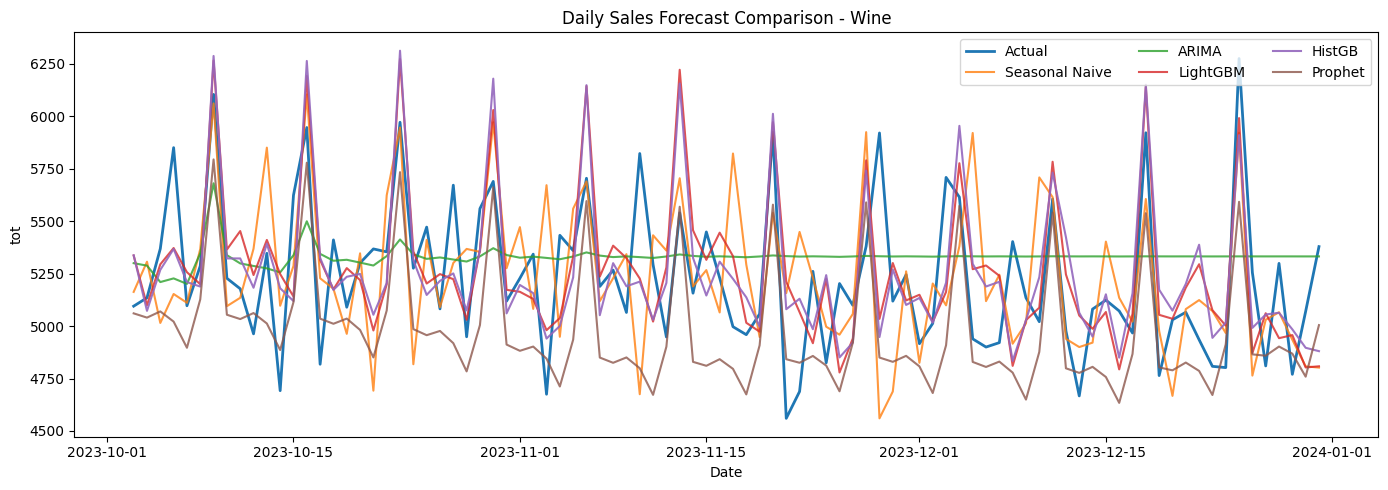

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(test["date_day"], y_test, label="Actual", linewidth=2)
plt.plot(test["date_day"], baseline_pred, label="Seasonal Naive", alpha=0.8)
plt.plot(test["date_day"], arima_pred, label="ARIMA", alpha=0.8)
plt.plot(test["date_day"], lgbm_pred, label="LightGBM", alpha=0.8)
plt.plot(test["date_day"], hgb_pred, label="HistGB", alpha=0.9)

if not np.isnan(prophet_pred).all():
    plt.plot(test["date_day"], prophet_pred, label="Prophet", alpha=0.8)

plt.title(f"Daily Sales Forecast Comparison - {top_cate}")
plt.xlabel("Date")
plt.ylabel("tot")
plt.legend(ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, f"forecast_model_comparison_{top_cate}.png"), dpi=150)
plt.show()


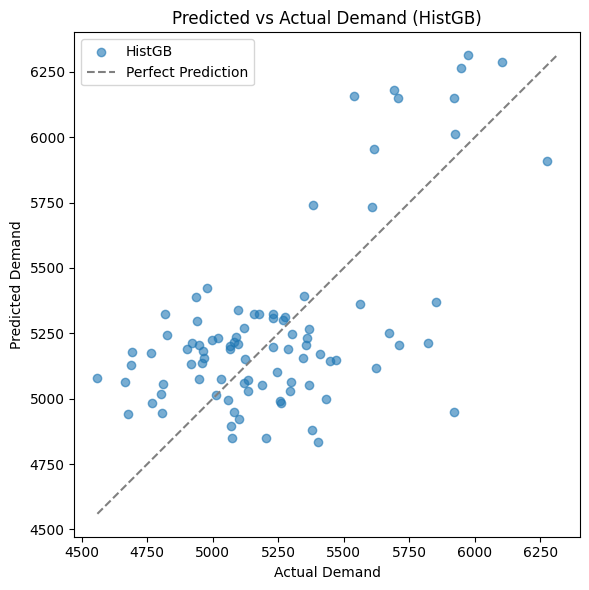

In [ ]:
# =========================================
# Forecast vs Actual Demand
# 목적: 최종 선택 모델의 예측값과 실제값 비교
# =========================================

# best model 자동 선택
best_model_name = comparison_df_rounded.iloc[0]["Model"]

pred_map = {
    "Seasonal Naive": baseline_pred,
    "ARIMA": arima_pred,
    "LightGBM": lgbm_pred,
    "HistGB": hgb_pred,
    "Prophet": prophet_pred
}

final_pred = pred_map[best_model_name]

import numpy as np
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    final_pred,
    alpha=0.6,
    label=best_model_name
)

# perfect prediction line
min_val = min(np.min(y_test), np.min(final_pred))
max_val = max(np.max(y_test), np.max(final_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="gray",
    label="Perfect Prediction"
)

plt.xlabel("Actual Demand")
plt.ylabel("Forecast Demand")
plt.title(f"Forecast vs Actual Demand ({best_model_name})")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(cfg.out_dir, f"Forecast_vs_actual_{best_model_name}.png"),
    dpi=150
)

plt.show()

### Insight

Most predictions lie close to the diagonal reference line,
indicating that the model captures the overall demand level reasonably well.

However, a mild regression-to-the-mean pattern is observed:
the model tends to slightly overpredict lower demand levels
and underpredict higher demand levels.

This suggests that extreme demand values remain more difficult
for the model to capture accurately.


## 7. Forecast Error Analysis

While overall metrics show that the feature-based model improves forecast accuracy,
aggregate metrics alone do not explain **where and why errors occur**.

To better understand the operational implications of forecasting errors,
the prediction results are analyzed across three perspectives:

1. **Top Error Days** – identifying dates with the largest prediction failures  
2. **Weekday Error Patterns** – analyzing systematic weekday effects  
3. **Demand Volume Segmentation** – understanding how errors vary by demand level  

This multi-perspective error analysis helps connect model performance
to **practical inventory risk scenarios**.

### 7.1 Forecast Error by Weekday

Demand patterns in retail often vary across weekdays due to
consumer behavior and operational factors.

To evaluate whether forecast errors follow a systematic weekly pattern,
RMSE is calculated separately for each weekday.

This analysis helps determine:

- whether certain weekdays consistently produce larger errors
- whether the feature-based model improves forecasting stability
  across different days of the week

Understanding weekday error patterns is important for
**operational planning and inventory allocation decisions**.

In [26]:

test_eval = test[["date_day"]].copy()
test_eval["y"] = y_test
test_eval["baseline"] = baseline_pred
test_eval["feature"] = hgb_pred
test_eval["weekday"] = pd.to_datetime(test_eval["date_day"]).dt.weekday

by_dow = (test_eval
          .groupby("weekday")
          .apply(lambda g: pd.Series({
              "n": len(g),
              "RMSE_feature": rmse(g["y"].values, g["feature"].values),
              "RMSE_baseline": rmse(g["y"].values, g["baseline"].values),
          }))
          .reset_index())

by_dow.to_csv(os.path.join(cfg.out_dir, "error_by_weekday_rmse.csv"), index=False)
by_dow


,weekday,n,RMSE_feature,RMSE_baseline
0,0,12.0,278.913606,267.485514
1,1,13.0,407.637740,547.139274
2,2,13.0,259.870827,307.711778
3,3,13.0,242.790841,226.220111
4,4,13.0,376.193063,574.522343
5,5,13.0,306.204906,329.918288
6,6,13.0,289.171655,358.147477


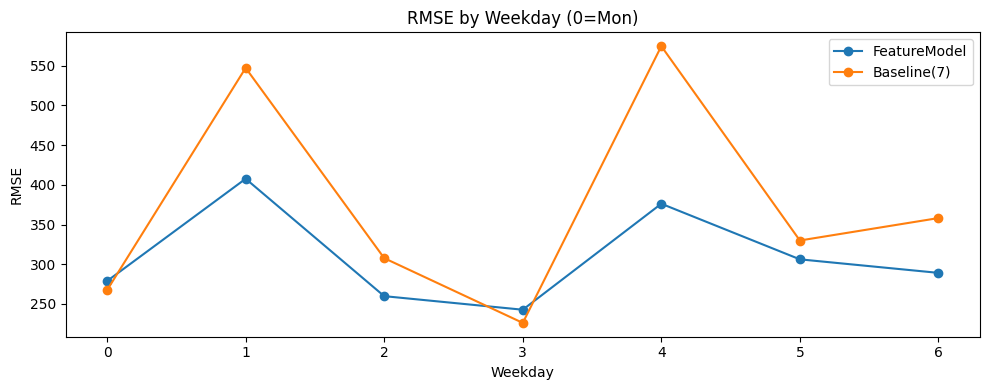

In [27]:

plt.figure(figsize=(10,4))
plt.plot(by_dow["weekday"], by_dow["RMSE_feature"], marker="o", label="FeatureModel")
plt.plot(by_dow["weekday"], by_dow["RMSE_baseline"], marker="o", label="Baseline(7)")
plt.title("RMSE by Weekday (0=Mon)")
plt.xlabel("Weekday"); plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "rmse_by_weekday.png"), dpi=150)
plt.show()


### 7.2 Top Error Days

To identify when the forecasting model fails most severely,
the dates with the largest absolute prediction errors are extracted.

Analyzing the highest-error dates helps answer several key questions:

- Are large errors associated with sudden demand spikes?
- Does the model systematically under-forecast or over-forecast?
- Which dates likely carried the highest operational inventory risk?

By focusing on extreme error cases,
we can better understand the **limitations of the forecasting model
under volatile demand conditions**.

In [28]:
# =========================================
# 테스트 구간에서 절대 오차가 가장 큰 날짜 10개를 추출
# → 모델 실패가 집중된 날짜를 식별
# =========================================

# test_eval: 테스트 구간의 실제값 / baseline / feature 예측값 포함 데이터프레임

test_eval = test_eval.copy()

# 절대 오차 / 방향성 오차 계산
test_eval["abs_error"] = np.abs(test_eval["y"] - test_eval["feature"])
test_eval["signed_error"] = test_eval["y"] - test_eval["feature"]

# 전일 대비 변동폭 계산
test_eval = test_eval.sort_values("date_day").reset_index(drop=True)
test_eval["prev_day"] = test_eval["y"].shift(1)
test_eval["delta_vs_prev_day"] = test_eval["y"] - test_eval["prev_day"]
test_eval["pct_change_vs_prev_day"] = np.where(test_eval["prev_day"].fillna(0).values == 0, np.nan,
    (test_eval["y"] - test_eval["prev_day"]) / test_eval["prev_day"] * 100
)

# 절대 오차 기준 상위 10일 추출
top10_errors = test_eval.sort_values("abs_error", ascending=False).head(10).copy()

# 결과 저장
top10_errors.to_csv(os.path.join(cfg.out_dir, "top10_error_days.csv"), index=False)

top10_errors

,date_day,y,baseline,feature,weekday,abs_error,signed_error,prev_day,delta_vs_prev_day,pct_change_vs_prev_day
56,2023-11-28,5921.0,4560.0,5047.726069,1,873.273931,873.273931,5381.0,540.0,10.035309
49,2023-11-21,4560.0,5157.0,5235.445884,1,675.445884,-675.445884,5925.0,-1365.0,-23.037975
14,2023-10-17,4818.0,5228.0,5450.254611,1,632.254611,-632.254611,5947.0,-1129.0,-18.984362
24,2023-10-27,5672.0,5301.0,5056.532245,4,615.467755,615.467755,5082.0,590.0,11.609603
41,2023-11-13,5540.0,5705.0,6145.422178,0,605.422178,-605.422178,4948.0,592.0,11.964430
38,2023-11-10,5823.0,4675.0,5226.072843,4,596.927157,596.927157,5065.0,758.0,14.965449
3,2023-10-06,5851.0,5153.0,5297.632594,4,553.367406,553.367406,5369.0,482.0,8.977463
61,2023-12-03,5709.0,5099.0,5161.464849,6,547.535151,547.535151,5013.0,696.0,13.883903
89,2023-12-31,5379.0,4802.0,4835.603041,6,543.396959,543.396959,5070.0,309.0,6.094675
11,2023-10-14,4692.0,5097.0,5196.442894,5,504.442894,-504.442894,5347.0,-655.0,-12.249860


### Insight

The largest errors occur on days with extreme demand spikes.

This suggests that the current model may struggle
to capture sudden changes in demand.

In [ ]:
# =========================================
# Top Error Case Visualization
# 가장 큰 오차가 발생한 날짜(top1)를 중심으로
# 실제값 / baseline / feature model을 비교
# =========================================

top1_date = top10_errors.iloc[0]["date_day"]

window = 7

case_df = test_eval[
    (test_eval["date_day"] >= top1_date - pd.Timedelta(days=window)) &
    (test_eval["date_day"] <= top1_date + pd.Timedelta(days=window))
].copy()

case_df

,date_day,y,baseline,feature,weekday,abs_error,signed_error,prev_day,delta_vs_prev_day,pct_change_vs_prev_day
49,2023-11-21,4560.0,5157.0,5235.445884,1,675.445884,-675.445884,5925.0,-1365.0,-23.037975
50,2023-11-22,4688.0,5449.0,5067.703038,2,379.703038,-379.703038,4560.0,128.0,2.807018
51,2023-11-23,5261.0,5230.0,4856.844253,3,404.155747,404.155747,4688.0,573.0,12.222696
52,2023-11-24,4825.0,4997.0,5188.386318,4,363.386318,-363.386318,5261.0,-436.0,-8.287397
53,2023-11-25,5203.0,4959.0,4805.820709,5,397.179291,397.179291,4825.0,378.0,7.834197
54,2023-11-26,5099.0,5058.0,4959.264898,6,139.735102,139.735102,5203.0,-104.0,-1.998847
55,2023-11-27,5381.0,5925.0,5728.005126,0,347.005126,-347.005126,5099.0,282.0,5.530496
56,2023-11-28,5921.0,4560.0,5047.726069,1,873.273931,873.273931,5381.0,540.0,10.035309
57,2023-11-29,5119.0,4688.0,5363.240399,2,244.240399,-244.240399,5921.0,-802.0,-13.545010
58,2023-11-30,5245.0,5261.0,5041.359595,3,203.640405,203.640405,5119.0,126.0,2.461418


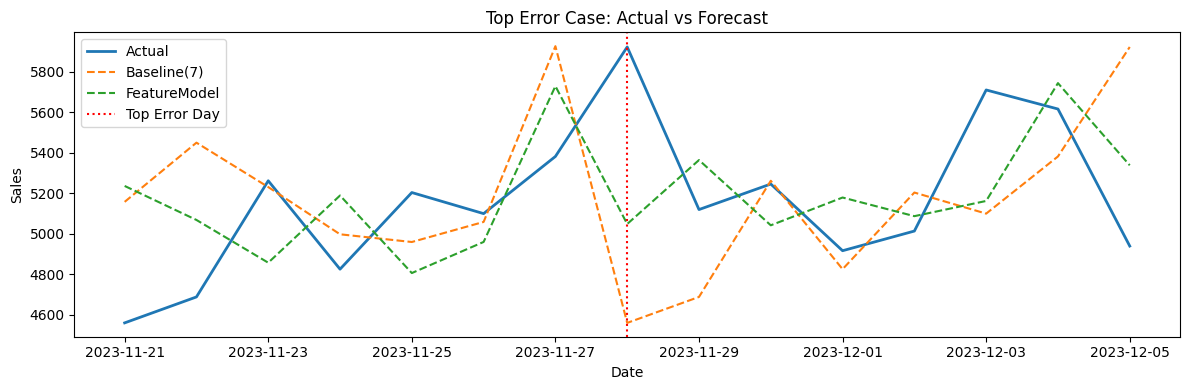

In [30]:
# =========================================
# Top1 Error Day Plot
# =========================================

plt.figure(figsize=(12,4))

plt.plot(case_df["date_day"], case_df["y"], label="Actual", linewidth=2)
plt.plot(case_df["date_day"], case_df["baseline"], label="Baseline(7)", linestyle="--")
plt.plot(case_df["date_day"], case_df["feature"], label="FeatureModel", linestyle="--")

plt.axvline(top1_date, color="red", linestyle=":", label="Top Error Day")

plt.title("Top Error Case: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(cfg.out_dir, "top1_error_case_plot.png"), dpi=150)
plt.show()

### 7.3 Error by Demand Volume

Forecasting difficulty often varies depending on the level of demand.

To analyze this effect, the test data is segmented into
three demand buckets based on sales volume:

- **Low demand**
- **Mid demand**
- **High demand**

For each segment, multiple error metrics (MAE, RMSE, WMAPE, sMAPE)
are calculated to understand how prediction accuracy varies
across demand conditions.

This segmentation helps identify where forecasting errors are most
likely to translate into **inventory risk**, particularly during
high-demand periods.

### Error vs Demand Level

A scatter plot of actual demand versus absolute forecast error
was examined to determine whether prediction error increases
as demand levels rise.

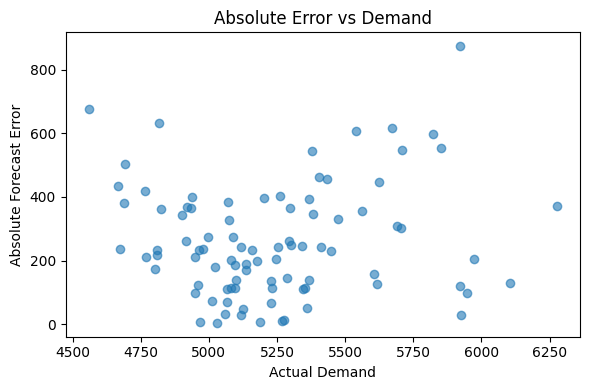

In [31]:
plt.figure(figsize=(6,4))

plt.scatter(
    test_eval["y"],
    np.abs(test_eval["y"] - test_eval["feature"]),
    alpha=0.6
)

plt.title("Absolute Error vs Demand")
plt.xlabel("Actual Demand")
plt.ylabel("Absolute Forecast Error")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "error_vs_demand_scatter.png"), dpi=150)
plt.show()

### Volume-based Error Segmentation

Forecast errors were segmented by demand volume to identify where prediction risk is concentrated.

This analysis helps answer:

- Is the model more stable in low, mid, or high demand periods?
- Which demand segment contributes most to operational inventory risk?

In [ ]:

q1, q2 = np.quantile(y_test, [0.33, 0.66])

def volume_bucket(v):
    if v <= q1: return "Low"
    if v <= q2: return "Mid"
    return "High"

test_eval["volume_bucket"] = [volume_bucket(v) for v in test_eval["y"].values]

seg = (test_eval
       .groupby("volume_bucket")
       .apply(lambda g: pd.Series({
           "n": len(g),
           "MAE": float(np.mean(np.abs(g["y"] - g["feature"]))),
           "RMSE": rmse(g["y"].values, g["feature"].values),
           "WMAPE(%)": wmape(g["y"].values, g["feature"].values),
           "sMAPE(%)": smape(g["y"].values, g["feature"].values),
       }))
       .reset_index())

seg = seg.set_index("volume_bucket").loc[["Low", "Mid", "High"]].reset_index()

seg.to_csv(os.path.join(cfg.out_dir, "error_segmentation_by_volume.csv"), index=False)
seg


,volume_bucket,n,MAE,RMSE,WMAPE(%),sMAPE(%)
0,Low,30.0,262.276755,311.270782,5.370745,5.239259
1,Mid,29.0,188.470300,220.740605,3.638544,3.692846
2,High,31.0,326.007104,383.697394,5.790468,5.948909


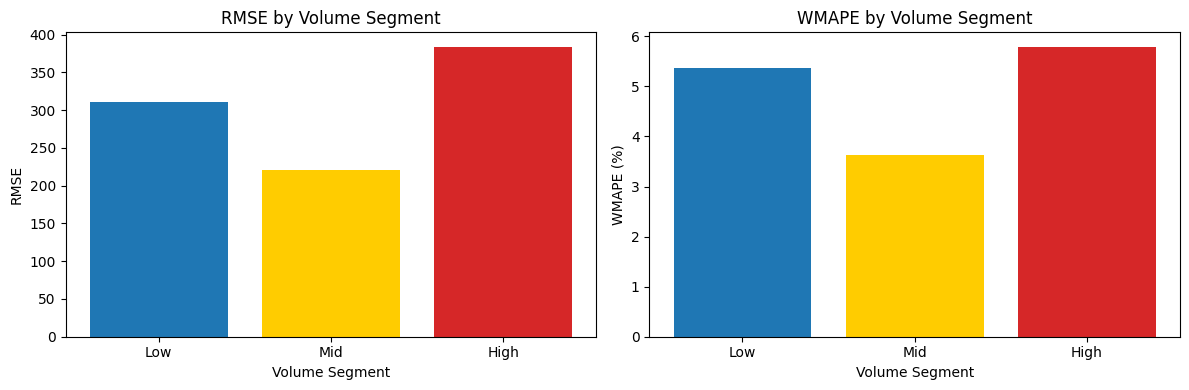

In [ ]:
# =========================================
# Volume Segmentation Comparison
# 절대 오차(RMSE)와 상대 오차(WMAPE)를 함께 비교
# =========================================

# segment color mapping
color_map = {
    "Low": "#1f77b4",   # blue
    "Mid": "#ffcc00",   # yellow
    "High": "#d62728"   # red
}

colors = [color_map[v] for v in seg["volume_bucket"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE
axes[0].bar(
    seg["volume_bucket"],
    seg["RMSE"],
    color=colors
)
axes[0].set_title("RMSE by Volume Segment")
axes[0].set_xlabel("Volume Segment")
axes[0].set_ylabel("RMSE")

# WMAPE
axes[1].bar(
    seg["volume_bucket"],
    seg["WMAPE(%)"],
    color=colors
)
axes[1].set_title("WMAPE by Volume Segment")
axes[1].set_xlabel("Volume Segment")
axes[1].set_ylabel("WMAPE (%)")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "segmentation_volume_comparison.png"), dpi=150)
plt.show()

### Insight

The scatter plot shows no strong linear relationship between demand level
and absolute forecast error.

However, segmentation analysis reveals that forecasting performance
still varies across different demand regimes.

The model performs most consistently in the **Mid-demand segment**,
while the **High-demand segment** exhibits the largest RMSE.

This indicates that the model handles typical demand conditions
reasonably well but struggles during periods of unusually high demand.
This behavior is consistent with the earlier error analysis,
where forecast errors were larger in high-demand segments.

These results suggest that forecast difficulty may depend more on
**demand regime** than on demand magnitude alone.

Future improvements may benefit from incorporating external variables
such as **promotions, marketing campaigns, or other demand-driving events**
to better capture sudden demand spikes.

### 7.4 Demand Spike Analysis

Segment-level analysis suggested that high-demand periods were harder to predict.

To investigate this further, I explicitly separated spike periods from normal periods and compared forecast errors between the two regimes.

This helps identify whether model failure is driven by general noise or by concentrated extreme-demand events.

In [61]:
# =========================================
# Demand Spike Error Analysis
# 목적:
# 수요 급증(spike) 구간에서 모델 오차가 얼마나 커지는지 정량 분석
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 최종 모델 예측값 선택
final_model_name = "HistGB"
final_pred = hgb_pred

# 평가용 데이터프레임
spike_eval = pd.DataFrame({
    "date_day": test["date_day"].values,
    "actual": y_test,
    "pred": final_pred
}).copy()

spike_eval["abs_error"] = np.abs(spike_eval["actual"] - spike_eval["pred"])
spike_eval["pct_error"] = spike_eval["abs_error"] / np.maximum(spike_eval["actual"], 1) * 100

# spike 기준: 상위 90퍼센타일 이상 actual demand
spike_threshold = spike_eval["actual"].quantile(0.90)
spike_eval["is_spike"] = spike_eval["actual"] >= spike_threshold

# 요약표
spike_summary = spike_eval.groupby("is_spike").agg(
    n_obs=("actual", "size"),
    avg_actual=("actual", "mean"),
    rmse=("abs_error", lambda x: np.sqrt(np.mean(np.square(x)))),
    mae=("abs_error", "mean"),
    mape_pct=("pct_error", "mean")
).reset_index()

spike_summary["segment"] = spike_summary["is_spike"].map({False: "Normal", True: "Spike"})
spike_summary = spike_summary[["segment", "n_obs", "avg_actual", "rmse", "mae", "mape_pct"]]
spike_summary.to_csv(os.path.join(cfg.out_dir, "spike_error_summary.csv"), index=False)

spike_summary

,segment,n_obs,avg_actual,rmse,mae,mape_pct
0,Normal,81,5154.419922,285.048828,241.233718,4.688947
1,Spike,9,5971.333496,471.177984,398.990387,6.711307


### Insight

Forecast errors increase during extreme demand spikes, which are difficult to predict
because they are often driven by exogenous factors such as promotions or external events.

## 8. Business Impact Simulation

While forecasting accuracy is typically evaluated using statistical metrics such as RMSE or WMAPE, these metrics do not directly explain how forecasting improvements affect real business operations.

To better understand the operational implications of improved forecasting performance, this section translates model performance into potential business impact.

First, the reduction in forecast error between the baseline model and the best-performing model is quantified.  
Next, a simplified inventory planning simulation is conducted to examine how forecast accuracy affects inventory decisions, stockout risk, and inventory holding costs.

### 8.1 Forecast Accuracy Impact

To interpret model performance in business terms, the reduction in forecast error is quantified between the seasonal baseline model and the best-performing machine learning model.

This provides a simple estimate of how much operational uncertainty can be reduced through improved forecasting accuracy.

In [78]:
# =========================================
# Business Impact Calculation
# =========================================

total_actual = float(np.sum(y_test))

abs_err_base = float(np.sum(np.abs(y_test - baseline_pred)))
abs_err_feat = float(np.sum(np.abs(y_test - hgb_pred)))

reduction = abs_err_base - abs_err_feat
daily_reduction = reduction / len(y_test)
monthly_reduction = daily_reduction * 30

impact = {
    "total_actual": total_actual,
    "abs_err_baseline": abs_err_base,
    "abs_err_feature": abs_err_feat,
    "error_reduction_total": reduction,
    "error_reduction_per_day": daily_reduction,
    "error_reduction_per_month": monthly_reduction,
}

pd.Series(impact).to_csv(
    os.path.join(cfg.out_dir, "business_impact_summary.csv")
)

# impact
pd.DataFrame([impact])


# total_actual	테스트 기간 총 실제 수요
# abs_err_base	baseline 모델의 총 절대오차
# abs_err_feat	최종 모델의 총 절대오차
# reduction	baseline 대비 줄어든 총 오차
# daily_reduction	하루 평균 오차 감소
# monthly_reduction	월 기준 오차 감소


,total_actual,abs_err_baseline,abs_err_feature,error_reduction_total,error_reduction_per_day,error_reduction_per_month
0,471250.0,26460.0,23130.844674,3329.155326,36.990615,1109.718442


### Insight

The feature-based forecasting model reduces total forecast error by **3,329 units** compared with the seasonal baseline.

This corresponds to roughly **37 units of error reduction per day**, or about **1,110 units per month**.

Although the daily improvement may appear modest, the accumulated reduction can meaningfully decrease uncertainty in demand planning and operational decision-making.


## 8.2 Inventory Optimization

Forecast accuracy improvements are most valuable when they translate into better operational decisions.

To illustrate this connection, a simplified inventory policy is simulated where planned inventory equals forecast demand plus a safety buffer.

This simulation allows us to evaluate the trade-off between stockout risk and overstock cost under different inventory buffer assumptions.

In [ ]:
# =========================================
# Inventory Risk Simulation
# 목적:
# 예측값 기반 재고 운영 시 stockout / overstock risk를 단순 시뮬레이션
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

final_model_name = "HistGB"
final_pred = hgb_pred

sim_df = pd.DataFrame({
    "date_day": test["date_day"].values,
    "actual_demand": y_test,
    "forecast": final_pred
}).copy()

# -----------------------------------------
# 재고 정책 가정
# stock = forecast + safety_buffer
# -----------------------------------------
service_buffer_ratio = 0.10   # 예측치의 10%를 safety buffer로 추가
holding_cost_per_unit = 2.0   # 과잉재고 단위당 비용 (가정)
stockout_cost_per_unit = 8.0  # 품절 단위당 기회비용 (가정)

sim_df["planned_inventory"] = np.ceil(sim_df["forecast"] * (1 + service_buffer_ratio))

# 실제 수요 대비 재고 결과
sim_df["overstock_units"] = np.maximum(sim_df["planned_inventory"] - sim_df["actual_demand"], 0)
sim_df["stockout_units"] = np.maximum(sim_df["actual_demand"] - sim_df["planned_inventory"], 0)

sim_df["holding_cost"] = sim_df["overstock_units"] * holding_cost_per_unit
sim_df["stockout_cost"] = sim_df["stockout_units"] * stockout_cost_per_unit
sim_df["total_cost"] = sim_df["holding_cost"] + sim_df["stockout_cost"]

inventory_summary = pd.DataFrame({
    "metric": [
        "avg_actual_demand",
        "avg_forecast",
        "avg_planned_inventory",
        "total_overstock_units",
        "total_stockout_units",
        "stockout_days",
        "overstock_days",
        "total_holding_cost",
        "total_stockout_cost",
        "total_inventory_cost"
    ],
    "value": [
        sim_df["actual_demand"].mean(),
        sim_df["forecast"].mean(),
        sim_df["planned_inventory"].mean(),
        sim_df["overstock_units"].sum(),
        sim_df["stockout_units"].sum(),
        (sim_df["stockout_units"] > 0).sum(),
        (sim_df["overstock_units"] > 0).sum(),
        sim_df["holding_cost"].sum(),
        sim_df["stockout_cost"].sum(),
        sim_df["total_cost"].sum()
    ]
})

inventory_summary.to_csv(os.path.join(cfg.out_dir, "inventory_simulation_summary.csv"), index=False)
sim_df.to_csv(os.path.join(cfg.out_dir, "inventory_simulation_daily.csv"), index=False)

inventory_summary

,metric,value
0,avg_actual_demand,5236.111328
1,avg_forecast,5267.575869
2,avg_planned_inventory,5794.800000
3,total_overstock_units,50944.000000
4,total_stockout_units,662.000000
5,stockout_days,4.000000
6,overstock_days,86.000000
7,total_holding_cost,101888.000000
8,total_stockout_cost,5296.000000
9,total_inventory_cost,107184.000000


### Insight

Under the 10% safety buffer assumption, stockout risk is relatively low, but the system experiences a substantial amount of overstock.

This highlights the fundamental trade-off in inventory management: increasing safety stock reduces stockout risk but increases inventory holding cost.

### Buffer Sensitivity Analysis

Because inventory outcomes depend heavily on the safety buffer policy, different buffer levels are tested to evaluate how inventory costs change under different operating strategies.

In [65]:
# =========================================
# Buffer Sensitivity Analysis
# 목적:
# safety buffer 비율에 따라 총 비용이 어떻게 달라지는지 확인
# =========================================

buffer_grid = np.arange(0.00, 0.31, 0.05)
sensitivity_rows = []

for b in buffer_grid:
    planned_inventory = np.ceil(sim_df["forecast"] * (1 + b))
    overstock_units = np.maximum(planned_inventory - sim_df["actual_demand"], 0)
    stockout_units = np.maximum(sim_df["actual_demand"] - planned_inventory, 0)

    holding_cost = overstock_units.sum() * holding_cost_per_unit
    stockout_cost = stockout_units.sum() * stockout_cost_per_unit
    total_cost = holding_cost + stockout_cost

    sensitivity_rows.append({
        "buffer_ratio": b,
        "total_overstock_units": overstock_units.sum(),
        "total_stockout_units": stockout_units.sum(),
        "holding_cost": holding_cost,
        "stockout_cost": stockout_cost,
        "total_cost": total_cost
    })

buffer_sensitivity_df = pd.DataFrame(sensitivity_rows)
buffer_sensitivity_df.to_csv(os.path.join(cfg.out_dir, "inventory_buffer_sensitivity.csv"), index=False)

buffer_sensitivity_df

,buffer_ratio,total_overstock_units,total_stockout_units,holding_cost,stockout_cost,total_cost
0,0.00,13010.0,10130.0,26020.0,81040.0,107060.0
1,0.05,29685.0,3100.0,59370.0,24800.0,84170.0
2,0.10,50944.0,662.0,101888.0,5296.0,107184.0
3,0.15,74223.0,231.0,148446.0,1848.0,150294.0
4,0.20,97694.0,0.0,195388.0,0.0,195388.0
5,0.25,121400.0,0.0,242800.0,0.0,242800.0
6,0.30,145104.0,0.0,290208.0,0.0,290208.0


### Insight

The buffer sensitivity analysis reveals a clear trade-off between stockout risk and inventory holding cost.

When the safety buffer is too small, stockout costs increase due to insufficient inventory during demand spikes.

When the buffer becomes too large, holding costs increase rapidly due to excess inventory.

The simulation suggests that a **5% safety buffer** provides the lowest total inventory cost under the current assumptions.

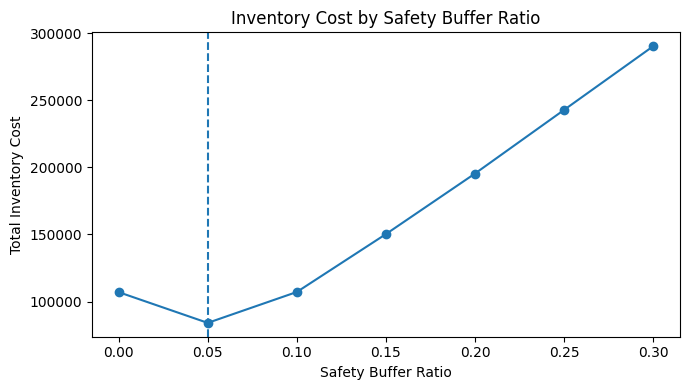

Best buffer ratio: 0.05
Minimum total cost: 84170.0


In [66]:
# =========================================
# Buffer Sensitivity Plot
# =========================================

best_row = buffer_sensitivity_df.loc[buffer_sensitivity_df["total_cost"].idxmin()]

plt.figure(figsize=(7, 4))
plt.plot(buffer_sensitivity_df["buffer_ratio"], buffer_sensitivity_df["total_cost"], marker="o")
plt.axvline(best_row["buffer_ratio"], linestyle="--")
plt.title("Inventory Cost by Safety Buffer Ratio")
plt.xlabel("Safety Buffer Ratio")
plt.ylabel("Total Inventory Cost")
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "inventory_cost_by_buffer_ratio.png"), dpi=150)
plt.show()

print("Best buffer ratio:", round(best_row["buffer_ratio"], 2))
print("Minimum total cost:", round(best_row["total_cost"], 2))

### Insight

The cost curve indicates that moderate safety buffers can achieve a better balance between stockout prevention and inventory efficiency than overly conservative inventory policies.

## 9. Conclusion & Recommendations

This project evaluated several forecasting approaches for short-term retail demand prediction using daily retail transaction data.

The analysis compared classical statistical models and machine learning models using RMSE, WMAPE, and walk-forward validation.

Key findings:

• Tree-based machine learning models outperformed classical statistical models.  
• HistGradientBoosting achieved the best overall forecasting performance.  
• Forecast errors were concentrated during high-demand spike periods.

From an operational perspective, improved forecast accuracy can support more reliable inventory planning.

The inventory simulation demonstrated that safety buffer policies significantly affect the trade-off between stockout risk and inventory holding cost.  
Under the assumptions used in this analysis, a **5% safety buffer produced the lowest total inventory cost**.

Overall, the results suggest that feature-based machine learning models combined with carefully tuned inventory policies can improve demand planning and operational efficiency.